# Prefilter Model — Inference Report

Evaluate the trained prefilter (DA) model on:
1. **MC test set** — parts not used in training (complement of `prefilter_h5_parts.json`)
2. **Experimental data** — `exp.h5` (raw hits only)
3. **Experimental reco data** — `exp_reco.h5` (raw hits + reconstruction features)

In [1]:
import sys, os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import load_model, load_mc_test_parts, \
    load_exp_parts, predict_scores, plot_event_3d

%load_ext autoreload
%autoreload 2

## Configuration

TODO: check if hard labeled model does better with Reco sample

In [2]:

# ── Paths ──
#CHECKPOINT_PATH = "experiments/numu/da_prefilter_numu_260327_0127/best_da_model.pth"
#CHECKPOINT_PATH = "experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/best_da_model.pth"
CHECKPOINT_PATH = f"experiments/numu/da_prefilter_numu_260329_2115_hardlabels_lambda0.0/best_da_model.pth"
TRAIN_PARTS_JSON = "/home2/albert/Baikal/datasets/baikal_mc2020_prefilter/prefilter_h5_parts.json"
MC_H5_PATH = "/net/62/home3/ivkhar/Baikal/data/h5s/baikal_mc_merged.h5"
EXP_H5_PATH = "data_manager/data/h5datasets/exp.h5"
EXP_RECO_H5_PATH = "data_manager/data/h5datasets/exp_reco.h5"

# ── MC test parts to load (from complement of training parts) ──
N_PARTS_PER_PARTICLE = {
    "muatm": 6,
    "nue2": 3,
    "nuatm": 3,
}

BAD_RECO_PARTS = [
    'part_s2020_c01_r0188',
    'part_s2020_c01_r0027',
    'part_s2020_c01_r0116'
 ]

# ── Inference settings ──
DEVICE = "cuda:1"
BATCH_SIZE = 1024
MAX_HITS = 500
SEED = 42

# ── reco_prty column mapping (index -> name) ──
RECO_COLUMNS = {
    0: "thetaRec",
    1: "phiRec",
    2: "thetaErr",
    3: "phiErr",
    4: "funcValue",
    5: "timeChi2",
    6: "chargeTerm",
    7: "LLFit",
    8: "nHits",
    9: "nStrings",
    10: "nOMs",
    11: "pathLength",
    12: "timeXYZRec",
}

# Recomended cuts:
# 1. funcValue/(fNHits-5)<30
# 2. pathLength>250 m

## 1. Load model

In [3]:
model, norm_config, train_config = load_model(
    str(PROJECT_ROOT / CHECKPOINT_PATH), device=DEVICE
)
print(f"Normalization: means={norm_config['means']}, stds={norm_config['stds']}")

2026-03-31 10:13:20,016 INFO Created AttentionFeatureExtractor: 5→64, 2 layers, 4 heads, pooling=cls
2026-03-31 10:13:20,019 INFO Created BinaryClassifier: 64→[32, 16]→1, dropout=0.0, batch_norm=False
2026-03-31 10:13:20,022 INFO Created StandardNeutrinoModel with 53633 parameters
2026-03-31 10:13:20,142 INFO Loaded model from epoch 92 (best_metric=0.9881)


Normalization: means=[2.0, 0.0, 0.0, 0.0, 0.0], stds=[60.0, 1370.0, 40.0, 40.0, 150.0]


## 2. Load data

In [4]:
# MC test set (complement of training parts)
df_mc = load_mc_test_parts(
    h5_path=MC_H5_PATH,
    train_parts_json=TRAIN_PARTS_JSON,
    n_parts_per_particle=N_PARTS_PER_PARTICLE,
    seed=SEED,
)
print(f"MC test: {len(df_mc):,} events")
print(df_mc["particle_type"].value_counts())

2026-03-31 10:13:20,253 INFO Loading 6 test parts for muatm_2020 (complement of 432 training parts)


MC muatm:   0%|          | 0/6 [00:00<?, ?part/s]

2026-03-31 10:13:23,995 INFO Loading 3 test parts for nue2_2020 (complement of 333 training parts)


MC nue2:   0%|          | 0/3 [00:00<?, ?part/s]

2026-03-31 10:13:25,291 INFO Loading 3 test parts for nuatm_2020 (complement of 187 training parts)


MC nuatm:   0%|          | 0/3 [00:00<?, ?part/s]

2026-03-31 10:13:28,272 INFO MC test set: 334,456 events loaded


MC test: 334,456 events
particle_type
muatm_2020    169148
nuatm_2020    108427
nue2_2020      56881
Name: count, dtype: int64


In [5]:
# Experimental data (raw)
df_exp = load_exp_parts(
    h5_path=str(PROJECT_ROOT / EXP_H5_PATH),
    group_name="exp",
    max_events=20_000
)
print(f"Exp: {len(df_exp):,} events")


Exp exp:   0%|          | 0/26 [00:00<?, ?part/s]

2026-03-31 10:13:39,246 INFO Loaded 20,000 events from /home/albert/Baikal2025/data_manager/data/h5datasets/exp.h5 (exp)


Exp: 20,000 events


In [6]:
with open(PROJECT_ROOT / Path(CHECKPOINT_PATH).parent / "used_target_event_ids.txt") as f:
    used_ids = [('_'.join(l.strip().split('_')[:-1]), l.strip().split('_')[-1]) for l in f.readlines()]
used_ids = pd.DataFrame(used_ids, columns=['h5_part_str', 'local_id'])
used_ids

,h5_part_str,local_id
0,exp_s2020_c01_r0027,0
1,exp_s2020_c01_r0027,2
2,exp_s2020_c01_r0027,6
3,exp_s2020_c01_r0027,7
4,exp_s2020_c01_r0027,10
...,...,...
299995,exp_s2020_c07_r0406,24990
299996,exp_s2020_c07_r0406,24991
299997,exp_s2020_c07_r0406,24993
299998,exp_s2020_c07_r0406,24998


In [7]:
# Experimental reco data (raw + reco_prty)
df_exp_reco = load_exp_parts(
    h5_path=str(PROJECT_ROOT / EXP_RECO_H5_PATH),
    group_name="exp_reco",
    load_reco=True,
)

df_exp_reco = df_exp_reco[(~df_exp_reco['h5_part_str'].isin(BAD_RECO_PARTS))]
print(f"Exp reco: {len(df_exp_reco):,} events")
reco_cols = [c for c in df_exp_reco.columns if c.startswith("reco_")]
print(f"Reco columns: {reco_cols}")

Exp exp_reco:   0%|          | 0/26 [00:00<?, ?part/s]

2026-03-31 10:13:50,445 INFO Loaded 333,675 events from /home/albert/Baikal2025/data_manager/data/h5datasets/exp_reco.h5 (exp_reco)


Exp reco: 267,035 events
Reco columns: ['reco_0', 'reco_1', 'reco_2', 'reco_3', 'reco_4', 'reco_5', 'reco_6', 'reco_7', 'reco_8', 'reco_9', 'reco_10', 'reco_11', 'reco_12']


In [8]:
df_exp_reco[df_exp_reco['reco_0']<60].shape[0]/df_exp_reco.shape[0]

0.009796468627707978

## 3. Predict scores

In [9]:
df_mc["score"] = predict_scores(
    model, df_mc["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"MC scores: mean={df_mc['score'].mean():.4f}, median={df_mc['score'].median():.4f}")

Predicting:   0%|          | 0/327 [00:00<?, ?batch/s]

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


MC scores: mean=0.4972, median=0.3272


In [10]:
df_exp["score"] = predict_scores(
    model, df_exp["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"Exp scores: mean={df_exp['score'].mean():.4f}, median={df_exp['score'].median():.4f}")

Predicting:   0%|          | 0/20 [00:00<?, ?batch/s]

Exp scores: mean=0.2994, median=0.1869


In [11]:
df_exp_reco["score"] = predict_scores(
    model, df_exp_reco["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"Exp reco scores: mean={df_exp_reco['score'].mean():.4f}, median={df_exp_reco['score'].median():.4f}")

Predicting:   0%|          | 0/261 [00:00<?, ?batch/s]

Exp reco scores: mean=0.0505, median=0.0002


## 4. Score distributions (MC by particle type)

TODO: mirror z in exp

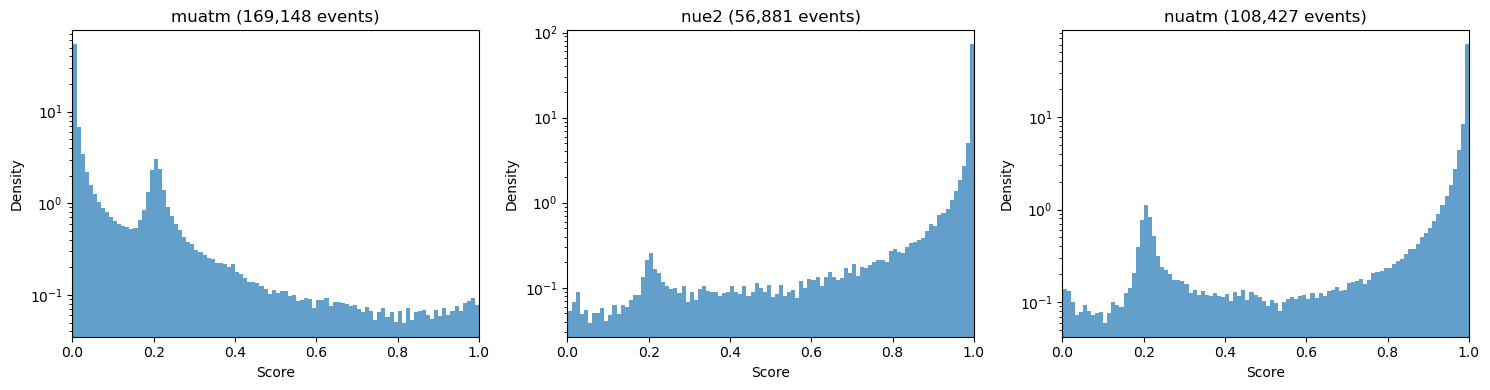

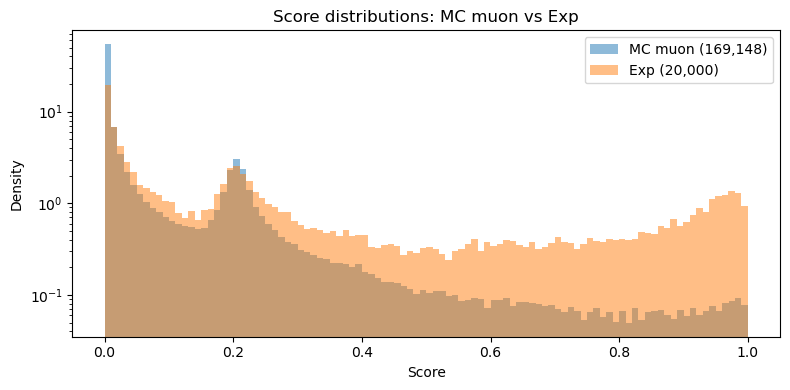

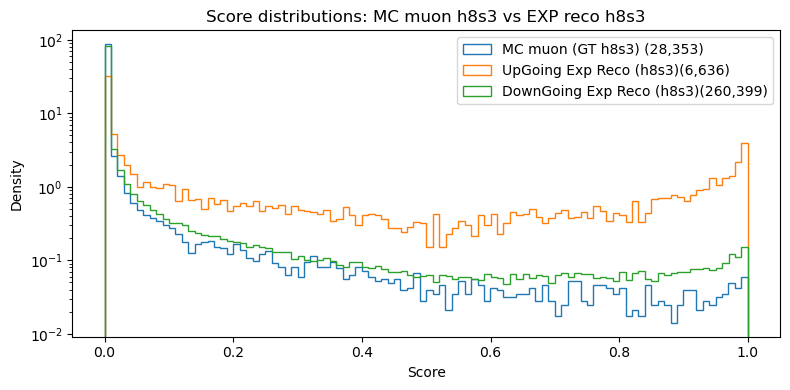

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution per particle type
for ax, ptype in zip(axes, ["muatm", "nue2", "nuatm"]):
    sub = df_mc[df_mc["particle_type"].str.startswith(ptype)]
    ax.hist(sub["score"], bins=100, alpha=0.7, log=True, density=True)
    ax.set_title(f"{ptype} ({len(sub):,} events)")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Score distribution: MC muons vs MC neutrinos vs Exp
fig, ax = plt.subplots(figsize=(8, 4))
mu = df_mc[df_mc["particle_type"].str.startswith("muatm")]["score"]
ax.hist(mu, bins=100, alpha=0.5, log=True, density=True, label=f"MC muon ({len(mu):,})")
#ax.hist(nu, bins=100, alpha=0.5, log=True, density=True, label=f"MC neutrino ({len(nu):,})")
ax.hist(df_exp["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp ({len(df_exp):,})")
#ax.hist(df_exp_reco["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp Reco (h8s3)({len(df_exp):,})")
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Score distributions: MC muon vs Exp")
plt.tight_layout()
plt.show()

# Score distribution: MC muons vs MC neutrinos vs Exp
fig, ax = plt.subplots(figsize=(8, 4))
mu = df_mc[(df_mc["particle_type"].str.startswith("muatm")) & (df_mc["n_signal_hits"]>=8) & (df_mc["n_signal_strings"]>=3)]["score"]
ax.hist(mu, bins=100, histtype='step', log=True, density=True, label=f"MC muon (GT h8s3) ({len(mu):,})")
#ax.hist(nu, bins=100, alpha=0.5, log=True, density=True, label=f"MC neutrino ({len(nu):,})")
#ax.hist(df_exp["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp ({len(df_exp):,})")
exp_reco_up_score = df_exp_reco["score"][df_exp_reco['reco_0']<80]
exp_reco_down_score = df_exp_reco["score"][df_exp_reco['reco_0']>=80]
ax.hist(exp_reco_up_score, bins=100, histtype='step', log=True, density=True, label=f"UpGoing Exp Reco (h8s3)({len(exp_reco_up_score):,})")
ax.hist(exp_reco_down_score, bins=100, histtype='step', log=True, density=True, label=f"DownGoing Exp Reco (h8s3)({len(exp_reco_down_score):,})")
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Score distributions: MC muon h8s3 vs EXP reco h8s3")
plt.tight_layout()
plt.show()

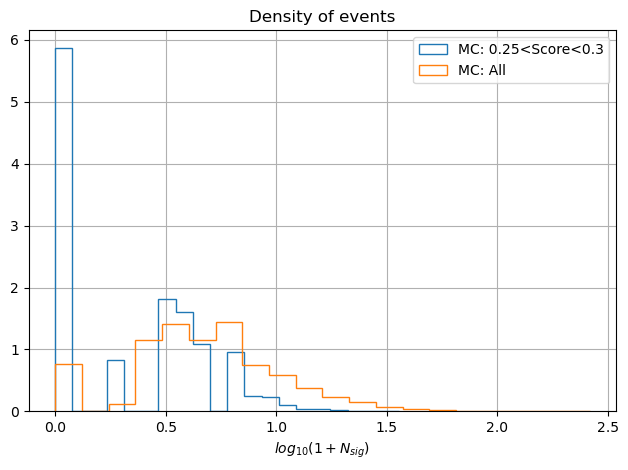

In [13]:
%matplotlib inline
plt.close()
df_mc[(df_mc['score']<0.3) & (df_mc['score']>0.25)]['n_signal_hits'].apply(lambda x: np.log10(x+1)).hist(bins=20, density=True, histtype='step', label='MC: 0.25<Score<0.3')
df_mc['n_signal_hits'].apply(lambda x: np.log10(x+1)).hist(bins=20, density=True, histtype='step', label='MC: All')
plt.xlabel(r"$log_{10}(1+N_{sig})$")
plt.title("Density of events")
plt.legend()
plt.tight_layout()
plt.show()

#### Analyze strange exp_reco events

###### 1. UpGoing events

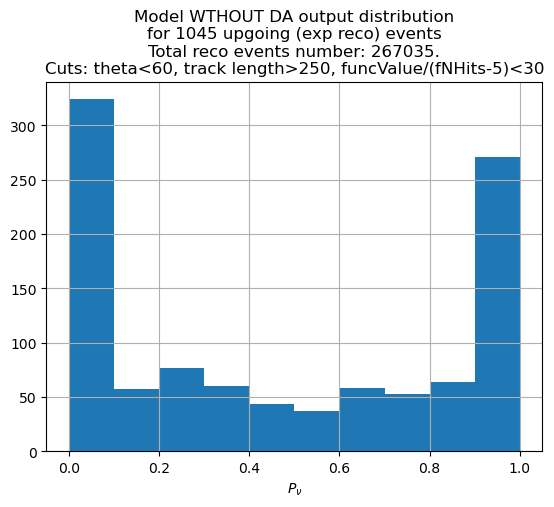

In [21]:
%matplotlib inline
theta_mask = (df_exp_reco['reco_0']<60)
path_length_mask = (df_exp_reco['reco_11']>250)
func_mask = (df_exp_reco['reco_4'] / (df_exp_reco['reco_10']-5) < 30)
df_upgoing_reco = df_exp_reco[theta_mask & path_length_mask & func_mask]
df_upgoing_reco['score'].hist(bins=10)
plt.title(f"Model WTHOUT DA output distribution\nfor {df_upgoing_reco.shape[0]} upgoing (exp reco) events\nTotal reco events number: {df_exp_reco.shape[0]}.\nCuts: theta<60, track length>250, funcValue/(fNHits-5)<30")
plt.xlabel(r"$P_{\nu}$")
plt.show()
plt.close()

In [15]:
df_upgoing_reco.shape[0], df_exp_reco.shape[0]

(238, 267035)

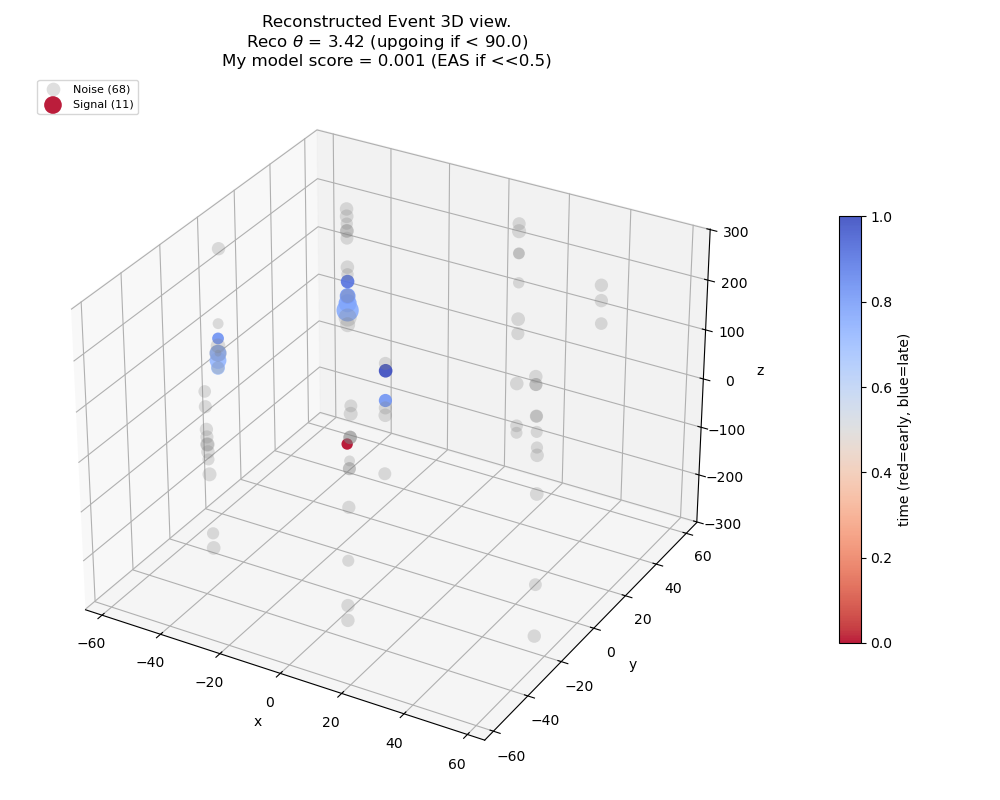

In [26]:
%matplotlib ipympl
plt.close()
score_mask = df_upgoing_reco['score']<0.1
event_idx = 2
event = df_upgoing_reco[score_mask].iloc[event_idx]

theta = event['reco_0']
score = event['score']
feats = event['features']
signal_mask = event['signal_mask']

theta_str = r"$\theta$"
plot_event_3d(feats, signal_mask, f"Reconstructed Event 3D view.\nReco {theta_str} = {theta:.2f} (upgoing if < 90.0)\nMy model score = {score:.3f} (EAS if <<0.5)")
plt.tight_layout()
plt.show()

In [ ]:
df_exp_reco

,h5_part_str,local_id,n_hits,features,reco_0,reco_1,reco_2,reco_3,reco_4,reco_5,reco_6,reco_7,reco_8,reco_9,reco_10,reco_11,reco_12,score
66640,part_s2020_c02_r0015,0,70,"[[0.64651656, -2693.5137, -0.69059163, -0.9745...",108.173538,308.058441,0.000000,0.000000,58.321106,51.991936,6.329170,0.0,11.0,4.0,11.0,169.225250,15852.087891,0.044080
66641,part_s2020_c02_r0015,1,65,"[[0.80287045, -2557.012, 43.289955, -42.00472,...",152.144119,84.901436,2.131575,4.193575,35.003647,18.406189,16.597458,0.0,8.0,2.0,8.0,128.923996,17122.060547,0.000416
66642,part_s2020_c02_r0015,2,90,"[[1.9397994, -2604.7747, -0.690378, -1.016866,...",111.282387,306.398224,0.486855,0.399242,217.819260,211.392960,6.426300,0.0,14.0,5.0,14.0,175.985687,16269.991211,0.000948
66643,part_s2020_c02_r0015,3,84,"[[0.8585947, -2448.145, -50.80372, -31.593527,...",100.348511,150.491394,0.758625,0.544812,89.717354,82.621811,7.095543,0.0,10.0,5.0,10.0,164.573990,16095.182617,0.990673
66644,part_s2020_c02_r0015,4,56,"[[1.4599409, -1881.5054, -2.851053, -56.80605,...",127.384041,54.921242,0.000000,0.000000,1630.318970,1608.529419,21.789551,0.0,8.0,5.0,8.0,190.080597,18063.324219,0.054331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333670,part_s2020_c07_r0406,8839,101,"[[1.0085741, -2400.3289, -32.914047, -48.523, ...",161.258667,97.453857,0.372670,1.572645,91.697060,74.749374,16.947685,0.0,11.0,2.0,11.0,324.718994,17683.681641,0.000015
333671,part_s2020_c07_r0406,8840,84,"[[0.9185242, -2670.5496, -33.05516, -47.706837...",139.192749,237.511032,0.715735,1.494696,174.804123,141.893463,32.910660,0.0,11.0,4.0,11.0,234.542786,16901.228516,0.000727
333672,part_s2020_c07_r0406,8841,83,"[[0.33432466, -2597.5125, 10.5872345, 57.36350...",114.394836,51.453808,0.486608,1.269741,17.651821,15.952344,1.699477,0.0,8.0,3.0,8.0,179.981674,18929.660156,0.043335
333673,part_s2020_c07_r0406,8842,99,"[[0.9432426, -2499.5037, 19.726364, -57.031025...",168.555756,260.996399,0.000000,0.000000,24.020998,19.985552,4.035446,0.0,9.0,3.0,9.0,580.882507,18048.353516,0.000034


###### 2. Bad T STD Found!

In [ ]:
df_strange_peak_reco = df_exp_reco[(df_exp_reco['score']>0.35) & (df_exp_reco['score']<0.45)]
df_strange_nu_reco = df_exp_reco[(df_exp_reco['score']>0.999)]

display(df_strange_peak_reco['h5_part_str'].value_counts())

display(df_strange_nu_reco['h5_part_str'].value_counts())

h5_part_str
part_s2020_c03_r0417    601
part_s2020_c03_r0263    552
part_s2020_c04_r0116    377
part_s2020_c05_r0377    281
part_s2020_c05_r0035    235
part_s2020_c03_r0012    126
part_s2020_c07_r0406    116
part_s2020_c02_r0015     79
part_s2020_c07_r0202     75
part_s2020_c05_r0116     74
part_s2020_c04_r0037     70
part_s2020_c07_r0120     68
part_s2020_c06_r0032     67
part_s2020_c05_r0270     48
part_s2020_c06_r0413     46
part_s2020_c06_r0134     42
part_s2020_c06_r0325     42
part_s2020_c07_r0041     38
part_s2020_c03_r0115     30
part_s2020_c02_r0149      5
part_s2020_c02_r0357      3
part_s2020_c02_r0206      2
Name: count, dtype: int64

h5_part_str
part_s2020_c03_r0417    25
part_s2020_c04_r0116    19
part_s2020_c05_r0377    18
part_s2020_c05_r0035    15
part_s2020_c03_r0263    13
part_s2020_c03_r0012     7
part_s2020_c06_r0325     6
part_s2020_c02_r0015     5
part_s2020_c06_r0134     4
part_s2020_c06_r0032     4
part_s2020_c07_r0406     4
part_s2020_c07_r0041     3
part_s2020_c03_r0115     2
part_s2020_c05_r0116     2
part_s2020_c06_r0413     2
part_s2020_c05_r0270     2
part_s2020_c07_r0202     2
part_s2020_c04_r0037     1
Name: count, dtype: int64

In [ ]:
hist_kwargs = dict(bins=50, histtype='step', density=True)
muh8s3 = df_mc[(df_mc["particle_type"].str.startswith("muatm")) & (df_mc["n_signal_hits"]>=8) & (df_mc["n_signal_strings"]>=3)]

# Q
df_strange_peak_reco['features'].apply(lambda x: np.log10(x[:,0].max())).explode().hist(label='from peak', **hist_kwargs)
df_strange_nu_reco['features'].apply(lambda x: np.log10(x[:,0].max())).explode().hist(label='from score=1 peak', **hist_kwargs)
df_exp_reco['features'].apply(lambda x: np.log10(x[:,0].max()))[::10].explode().hist(label='Full exp reco', **hist_kwargs)
muh8s3['features'].apply(lambda x: np.log10(x[:,0].max())).explode().hist(label='MC muatm h8s3', **hist_kwargs)
plt.title(f"Max Q hists")
plt.legend()
plt.show()

# Z
df_strange_peak_reco['features'].apply(lambda x: x[:,4].mean()).explode().hist(label='from peak', **hist_kwargs)
df_strange_nu_reco['features'].apply(lambda x: x[:,4].mean()).explode().hist(label='from score=1 peak', **hist_kwargs)
df_exp_reco['features'].apply(lambda x: x[:,4].mean())[::10].explode().hist(label='Full exp reco', **hist_kwargs)
muh8s3['features'].apply(lambda x: x[:,4].mean()).explode().hist(label='MC muatm h8s3', **hist_kwargs)
plt.legend()
plt.title(f"Mean Z coord")
plt.show()
print()

# T
df_strange_peak_reco['features'].apply(lambda x: x[:,1].std()).explode().hist(label='from peak', **hist_kwargs)
df_strange_nu_reco['features'].apply(lambda x: x[:,1].std()).explode().hist(label='from score=1 peak', **hist_kwargs)
df_exp_reco['features'].apply(lambda x: x[:,1].std())[::10].explode().hist(label='Full exp reco', **hist_kwargs)
muh8s3['features'].apply(lambda x: x[:,1].std()).explode().hist(label='MC muatm h8s3', **hist_kwargs)
plt.legend()
plt.title(f"STD T")
plt.show()
print()

Plot STD T by parts (runs)

In [ ]:
print("Std time")
for cluster in ['c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07']:
    for part in sorted(df_exp_reco['h5_part_str'].unique()):
        if cluster not in part:
            continue
        part_df = df_exp_reco[df_exp_reco['h5_part_str']==part]
        t_std = part_df['features'].apply(lambda x: x[:,1].std())
        t_std.hist(label=part, **hist_kwargs)
    plt.title(f"Cluster {cluster}")
    plt.legend()
    plt.show()

In [ ]:
print("Std time in exp NOT RECO")
for cluster in ['c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07']:
    for part in sorted(df_exp['h5_part_str'].unique()):
        if cluster not in part:
            continue
        part_df = df_exp[df_exp['h5_part_str']==part]
        t_std = part_df['features'].apply(lambda x: x[:,1].std())
        t_std.hist(label=part, **hist_kwargs)
    plt.title(f"Cluster {cluster}")
    plt.legend()
    plt.show()

In [ ]:
df_exp_reco[df_exp_reco['h5_part_str']=='part_s2020_c04_r0117']

,h5_part_str,local_id,n_hits,features,reco_0,reco_1,reco_2,reco_3,reco_4,reco_5,reco_6,reco_7,reco_8,reco_9,reco_10,reco_11,reco_12,score
223230,part_s2020_c04_r0117,0,113,"[[1.2243562, -2480.6475, -2.0642176, 1.2939928...",116.282829,226.110962,0.945709,0.965099,5.203848,0.985032,4.218816,0.0,7.0,4.0,7.0,164.653061,15502.784180,0.742327
223231,part_s2020_c04_r0117,1,93,"[[0.85794103, -2397.5015, 49.817173, 30.217943...",171.767563,173.483887,0.000000,0.000000,19.296799,9.230155,10.066644,0.0,7.0,3.0,7.0,574.583679,17118.787109,0.865269
223232,part_s2020_c04_r0117,2,66,"[[0.5412813, -2431.2603, 53.20798, -19.886854,...",141.419937,126.894264,1.285834,1.427009,8.296103,7.065737,1.230366,0.0,7.0,3.0,7.0,247.682785,18043.593750,0.000096
223233,part_s2020_c04_r0117,3,76,"[[0.75272864, -2249.4138, -2.0187502, 1.244859...",114.704231,221.638382,1.412724,0.676131,44.349228,41.080963,3.268265,0.0,8.0,3.0,8.0,132.768478,15613.127930,0.000928
223234,part_s2020_c04_r0117,4,114,"[[1.1355946, -2745.453, 53.058712, -19.837477,...",110.159546,94.775932,0.635568,1.088606,136.245087,133.163895,3.081192,0.0,9.0,3.0,9.0,155.004303,18179.507812,0.991784
223235,part_s2020_c04_r0117,5,119,"[[157.9961, -2573.1316, 49.74805, 30.18532, 26...",107.270096,124.512184,0.522267,0.577248,24.926226,15.863966,9.062260,0.0,10.0,3.0,10.0,151.489548,17905.207031,0.808434


## 5. Precision-Recall curves (MC)

Binary labels for PR evaluation: **signal** = neutrino events with `n_signal_hits >= h_threshold`, **background** = everything else.

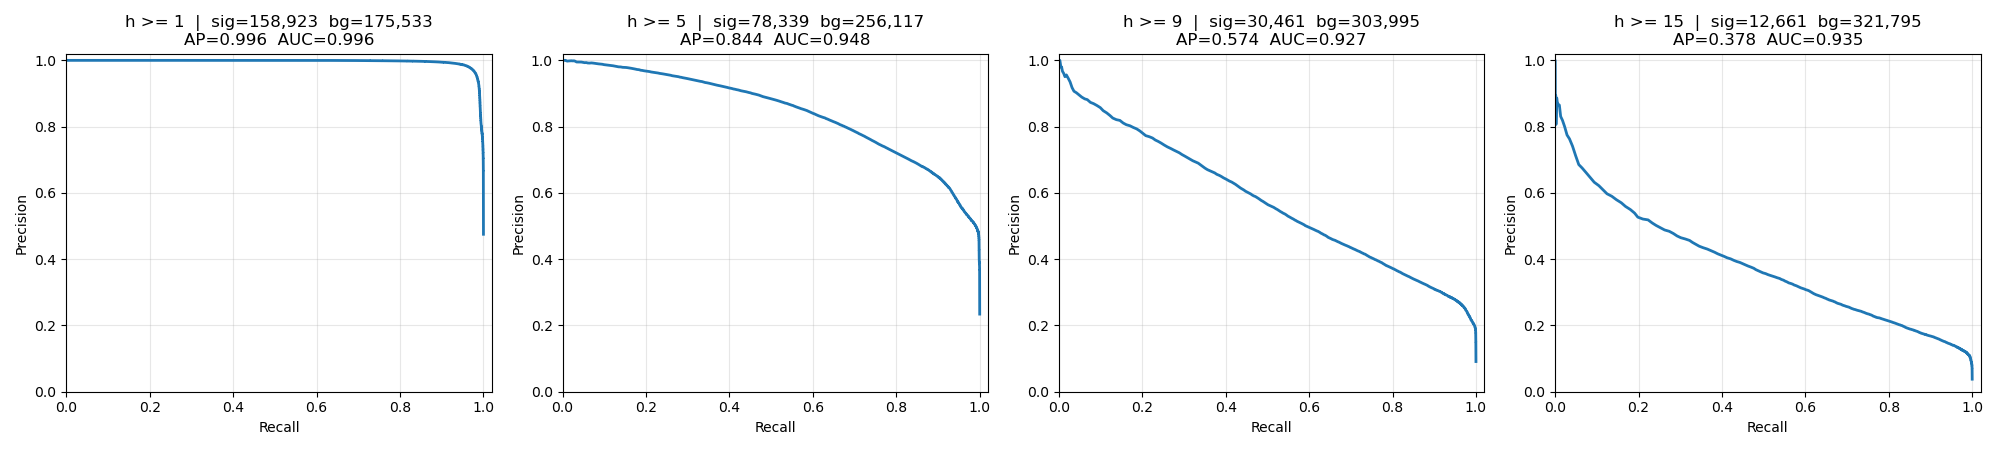

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

# Assign binary labels: neutrino = signal candidate, muon = background
df_mc["is_neutrino"] = df_mc["particle_type"].str.startswith("nu")

# PR curves at different signal-hit thresholds
H_THRESHOLDS = [1, 5, 9, 15]

fig, axes = plt.subplots(1, len(H_THRESHOLDS), figsize=(5 * len(H_THRESHOLDS), 4.5))

for ax, h_thr in zip(axes, H_THRESHOLDS):
    # Signal: neutrino with >= h_thr signal hits; Background: everything else
    binary_label = (df_mc["is_neutrino"] & (df_mc["n_signal_hits"] >= h_thr)).astype(int)
    scores = df_mc["score"].values

    n_sig = binary_label.sum()
    n_bg = len(binary_label) - n_sig

    if n_sig == 0 or n_bg == 0:
        ax.set_title(f"h >= {h_thr}\n(no signal or bg)")
        continue

    precision, recall, thresholds = precision_recall_curve(binary_label, scores)
    ap = average_precision_score(binary_label, scores)
    auc = roc_auc_score(binary_label, scores)

    ax.plot(recall, precision, lw=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"h >= {h_thr}  |  sig={n_sig:,}  bg={n_bg:,}\nAP={ap:.3f}  AUC={auc:.3f}")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Using h_saturate=8 from training config


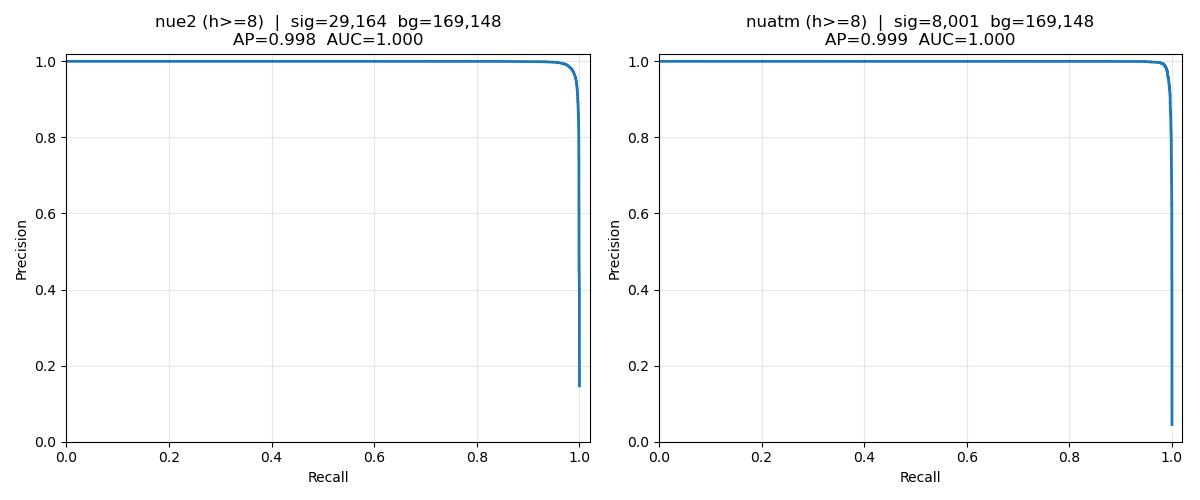

In [20]:
# PR curve split by neutrino type (nue2 vs nuatm) at h_saturate from training
H_SAT = 8 #train_config.get("data", {}).get("source_domain", {}).get("soft_labels", {}).get("h_saturate", 9)
print(f"Using h_saturate={H_SAT} from training config")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nu_type in zip(axes, ["nue2", "nuatm"]):
    # Signal: this neutrino type with >= H_SAT signal hits
    # Background: muons + low-signal neutrinos of this type
    mask_sig = (df_mc["particle_type"].str.startswith(nu_type)) & (df_mc["n_signal_hits"] >= H_SAT)
    mask_bg = (df_mc["particle_type"].str.startswith('muatm')) | (
        (df_mc["particle_type"] == nu_type) & (df_mc["n_signal_hits"] < H_SAT)
    )
    sub = df_mc[mask_sig | mask_bg]
    binary_label = mask_sig[sub.index].astype(int)
    scores = sub["score"].values

    n_sig = binary_label.sum()
    n_bg = len(binary_label) - n_sig

    precision, recall, _ = precision_recall_curve(binary_label, scores)
    ap = average_precision_score(binary_label, scores)
    auc = roc_auc_score(binary_label, scores)

    ax.plot(recall, precision, lw=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{nu_type} (h>={H_SAT})  |  sig={n_sig:,}  bg={n_bg:,}\nAP={ap:.3f}  AUC={auc:.3f}")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5c. Signal Efficiency & Background Suppression vs threshold

Twin y-axes: **TPR** (solid, left) and **1/FPR** (dashed, right, log scale) vs classification threshold.

Quality cuts applied symmetrically to both signal and background:
- `No cuts` — all events
- `hits>=8, strings>=2` — `n_signal_hits >= 8` **and** `n_signal_strings >= 2`

Case 1 (both nu types): positives subsampled to match muon count. Dotted vertical line marks **TPR = 99%** for the quality cut, with suppression annotated.

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve

# ── Config ──
HIT_CUTS   = [0, 8]
CUT_COLORS = ["grey", None]   # None = default color cycle
CUT_LABELS = ["No cuts", "hits>=8, strings>=2"]
SUPP_CLIP  = 10_000
REF_H      = 8
REF_TPR_TARGET = 0.99

# ── Precompute arrays ──
scores     = df_mc["score"].values
sig_hits   = df_mc["n_signal_hits"].values
sig_strs   = df_mc["n_signal_strings"].values
is_nu      = df_mc["is_neutrino"].values
is_muon    = ~is_nu
ptypes_arr = df_mc["particle_type"].values


def make_quality_mask(h: int) -> np.ndarray:
    """h=0: all events; h>0: signal_hits >= h AND signal_strings >= 2."""
    if h == 0:
        return np.ones(len(df_mc), dtype=bool)
    return (sig_hits >= h) & (sig_strs >= 2)


def balanced_subsample(pos_mask: np.ndarray, seed: int = 42) -> np.ndarray:
    """Subsample positives down to muon count, return mask."""
    n_neg = int(is_muon.sum())
    pos_idx = np.where(pos_mask)[0]
    chosen = np.random.default_rng(seed).choice(pos_idx, size=min(n_neg, len(pos_idx)), replace=False)
    m = np.zeros(len(df_mc), dtype=bool)
    m[chosen] = True
    return m


def get_ref_threshold(pos_mask: np.ndarray, sub_mask: np.ndarray = None):
    """Threshold where TPR ~ REF_TPR_TARGET for REF_H quality cut."""
    base_pos = pos_mask if sub_mask is None else (pos_mask & sub_mask)
    quality = make_quality_mask(REF_H)
    keep = (base_pos & quality) | (is_muon & quality)
    y_true = base_pos[keep].astype(int)
    y_score = scores[keep]
    fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
    # Reverse to ascending threshold order
    thr_arr = thr_arr[1:][::-1]
    tpr_arr = tpr_arr[1:][::-1]
    fpr_arr = fpr_arr[1:][::-1]
    inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
    idx = np.searchsorted(-tpr_arr, -REF_TPR_TARGET)
    idx = min(idx, len(thr_arr) - 1)
    return float(thr_arr[idx]), float(inv_fpr[idx])


def plot_tpr_suppression(ax, pos_mask, title, sub_mask=None):
    """Plot TPR (left y) and 1/FPR (right y, log) vs threshold."""
    ax_supp = ax.twinx()
    ax_supp.set_yscale("log")

    tpr_handles, supp_handles = [], []

    for h, color, lbl in zip(HIT_CUTS, CUT_COLORS, CUT_LABELS):
        base_pos = pos_mask if sub_mask is None else (pos_mask & sub_mask)
        quality = make_quality_mask(h)
        keep = (base_pos & quality) | (is_muon & quality)
        y_true = base_pos[keep].astype(int)
        y_score = scores[keep]
        n_sig, n_bg = y_true.sum(), (~y_true.astype(bool)).sum()
        if n_sig == 0 or n_bg == 0:
            continue

        fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
        thr_arr = thr_arr[1:][::-1]
        tpr_arr = tpr_arr[1:][::-1]
        fpr_arr = fpr_arr[1:][::-1]
        inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
        clip = (thr_arr >= 0) & (thr_arr <= 1)

        ax.plot(thr_arr[clip], tpr_arr[clip], color=color, lw=2, ls="-")
        ax_supp.plot(thr_arr[clip], inv_fpr[clip], color=color, lw=2, ls="--")

        tpr_handles.append(Line2D([0], [0], color=color, lw=2, ls="-",
                                  label=f"{lbl} (sig={n_sig:,})"))
        supp_handles.append(Line2D([0], [0], color=color, lw=2, ls="--", label=lbl))

    # Reference vertical line at TPR=99%
    ref_thr, ref_supp = get_ref_threshold(pos_mask, sub_mask)
    ref_supp_clipped = min(ref_supp, SUPP_CLIP)
    ax.axvline(ref_thr, color="red", lw=1.4, ls=":")
    tpr_handles.append(Line2D([0], [0], color="red", lw=1.4, ls=":",
                               label=f"Saving {int(REF_TPR_TARGET*100)}% nu @ thr={ref_thr:.3f}"))
    ax_supp.annotate(
        f"Supp={ref_supp:.0f}", xy=(ref_thr, ref_supp_clipped),
        xytext=(ref_thr - 0.21, ref_supp_clipped=
        fontsize=11, color="red", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="red", lw=1.2), va="center",
    )

    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax_supp.set_ylim(bottom=1)
    ax.set_xlabel("Classification threshold", fontsize=12)
    ax.set_ylabel(r"$\nu$ Efficiency (TPR)", fontsize=11)
    ax_supp.set_ylabel(r"EAS Suppression ($FPR^{-1}$)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.grid(which="major", alpha=0.3); ax.grid(which="minor", alpha=0.12)

    ax.legend(handles=tpr_handles, fontsize=8.5, loc=(0.01, 0.72),
              framealpha=0.85, title="Efficiency (solid)", title_fontsize=8.5)
    ax_supp.legend(handles=supp_handles, fontsize=8.5, loc=(0.7, 0.35),
                   framealpha=0.85, title="Suppression (dashed)", title_fontsize=8.5)
    return ax_supp

Case 1 balanced: 165,308 positives / 169,148 negatives


/tmp/ipykernel_1071806/1598880337.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1071806/1598880337.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1071806/1598880337.py:51: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_1071806/1598880337.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1071806/1598880337.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1071806/1598880337.py:51: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr

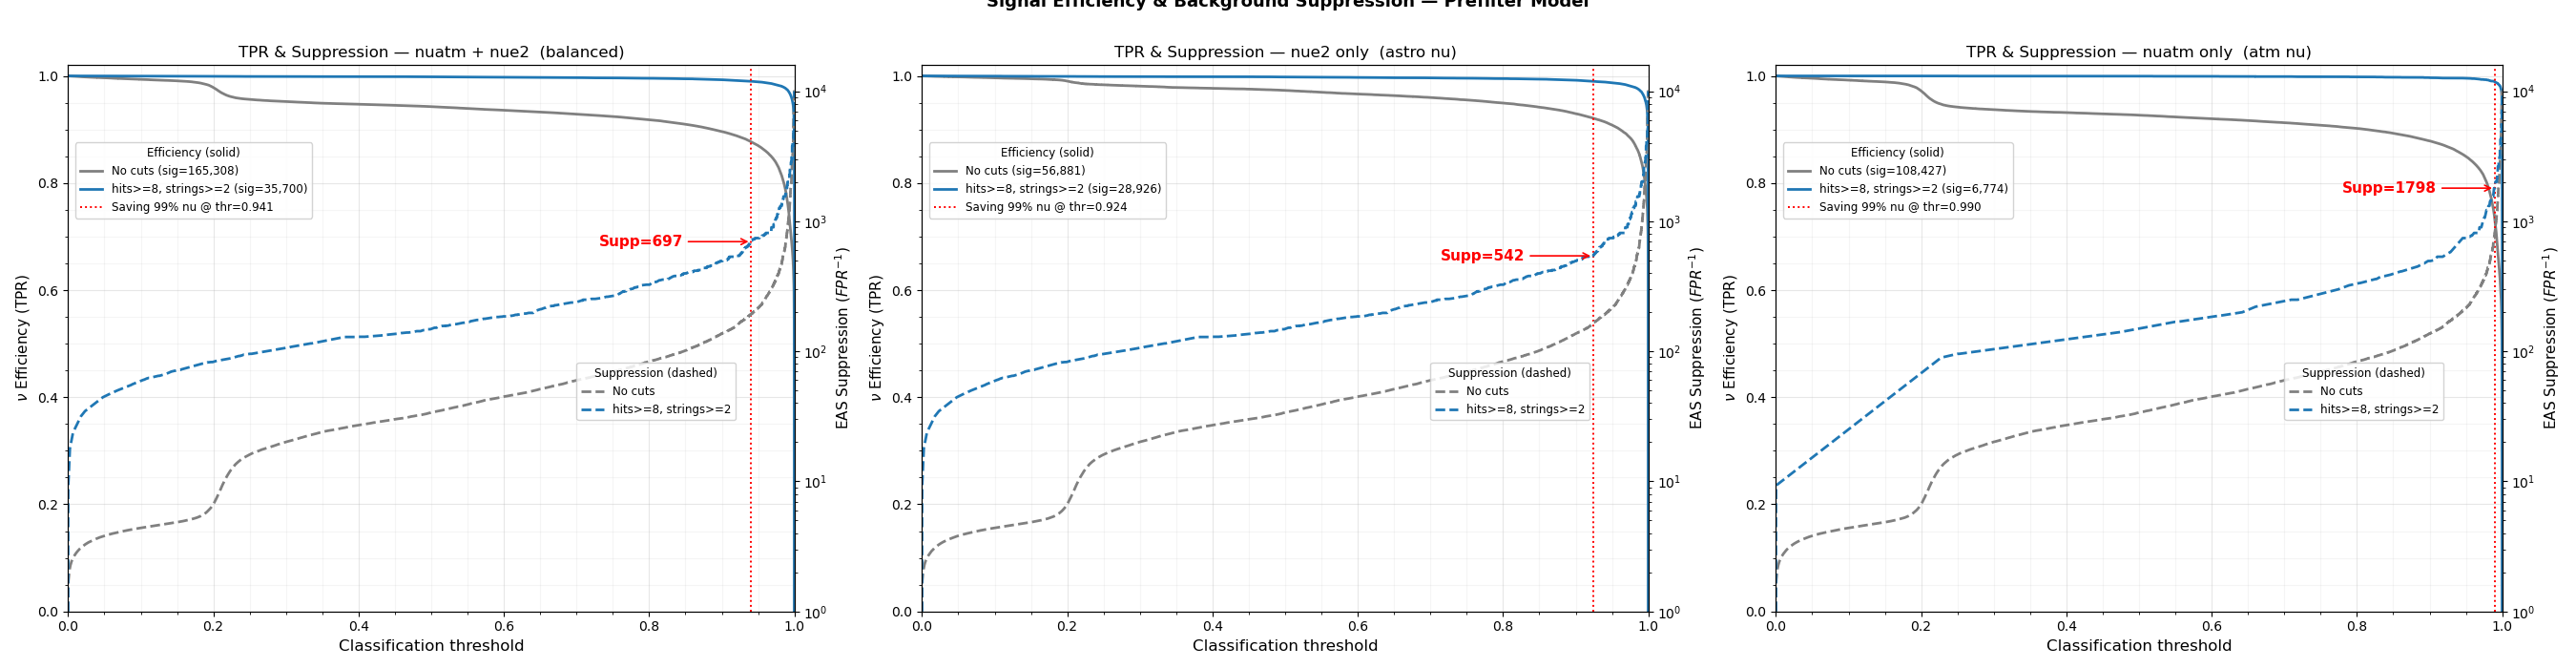

In [22]:
# ── Case 1: Both nuatm + nue2 as signal (balanced) ──
pos_both = is_nu.copy()
sub_both = balanced_subsample(pos_both)
n_pos = (pos_both & sub_both).sum()
n_neg = is_muon.sum()
print(f"Case 1 balanced: {n_pos:,} positives / {n_neg:,} negatives")

# ── Case 2: nue2 only ──
pos_nue2 = (ptypes_arr == "nue2_2020")

# ── Case 3: nuatm only ──
pos_nuatm = (ptypes_arr == "nuatm_2020")

# ── Combined 3x1 figure ──
fig, axes = plt.subplots(1, 3, figsize=(27, 7))

cases = [
    (pos_both,  sub_both, "nuatm + nue2  (balanced)"),
    (pos_nue2,  None,     "nue2 only  (astro nu)"),
    (pos_nuatm, None,     "nuatm only  (atm nu)"),
]

for ax, (pos_mask, sub_mask, label) in zip(axes, cases):
    plot_tpr_suppression(ax, pos_mask, title=f"TPR & Suppression — {label}", sub_mask=sub_mask)

fig.suptitle(
    f"Signal Efficiency & Background Suppression — Prefilter Model",
    fontsize=13, fontweight="bold", y=1.01,
)
fig.tight_layout()
plt.show()

## 6. Summary table

In [ ]:
summary_rows = []
for h_thr in H_THRESHOLDS:
    binary_label = (df_mc["is_neutrino"] & (df_mc["n_signal_hits"] >= h_thr)).astype(int).values
    scores = df_mc["score"].values
    n_sig = binary_label.sum()
    n_bg = len(binary_label) - n_sig
    if n_sig > 0 and n_bg > 0:
        ap = average_precision_score(binary_label, scores)
        auc = roc_auc_score(binary_label, scores)
    else:
        ap, auc = float("nan"), float("nan")
    summary_rows.append({
        "h_threshold": h_thr,
        "n_signal": n_sig,
        "n_background": n_bg,
        "AUC": round(auc, 4),
        "AP": round(ap, 4),
    })

pd.DataFrame(summary_rows)

,h_threshold,n_signal,n_background,AUC,AP
0,1,104917,117669,0.9674,0.9679
1,5,52857,169729,0.9221,0.7934
2,9,21295,201291,0.9177,0.5397
3,15,9056,213530,0.9280,0.3565


## 7. To be planned

In [ ]:
# TODO: further analysis